In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import nidaqmx
import matplotlib.animation as animation
from nidaqmx.constants import AcquisitionType, TerminalConfiguration

import datetime as datetime
from IPython.display import clear_output
import time

In [2]:
#para saber el ID de la placa conectada (DevX)
system = nidaqmx.system.System.local()
for device in system.devices:
    print(device)

Device(name=Dev1)


In [27]:
def save_measurement(t, V, comment=""):
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"data/measurement_{timestamp}.csv"
    
    header = f"Comment: {comment}\nTime (s),Voltage (V)"
    data = np.column_stack((t, V))
    
    np.savetxt(filename, data, delimiter=",", header=header, comments="")
    print(f"Saved to {filename}")

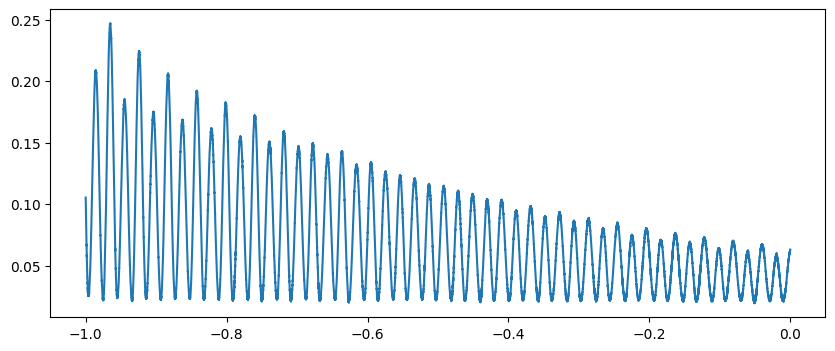

Collected 250000 samples (10.00 seconds)


In [ ]:
sample_rate = 25000
samples_per_read = 2500
buffer_size = 25000        # se muestra solamente un segundo de data
duration_seconds = 10
channel_name = "Dev1/ai1"


task = nidaqmx.Task()
task.ai_channels.add_ai_voltage_chan(channel_name, terminal_config=TerminalConfiguration.RSE)
task.timing.cfg_samp_clk_timing(
    sample_rate,
    sample_mode=AcquisitionType.CONTINUOUS,
    samps_per_chan=samples_per_read
)
task.start()

display_buffer = np.zeros(buffer_size)
all_data = []

# negativo pq es el segundo que ya paso jaj
time_axis = np.linspace(-buffer_size/sample_rate, 0, buffer_size)

start_time = time.time()


plot_interval = 0.2  # seconds
last_plot = time.time()

try:
    while (time.time() - start_time) < duration_seconds:
        data = task.read(number_of_samples_per_channel=samples_per_read)
        all_data.extend(data)

        display_buffer = np.roll(display_buffer, -samples_per_read)
        display_buffer[-samples_per_read:] = data

        # clear_output(wait=True)
        # fig, ax = plt.subplots(figsize=(10, 4))
        # ax.plot(time_axis, display_buffer)
        # ax.set_xlabel("tiempo [s]")
        # ax.set_ylabel("Tension [V]")
        # ax.set_title(f"medición a {sample_rate} Hz")
        # ax.set_ylim(display_buffer.min() - 0.1, display_buffer.max() + 0.1)
        # ax.grid(True)
        # plt.tight_layout()
        # plt.show()
        if time.time() - last_plot > plot_interval:
            clear_output(wait=True)

            fig, ax = plt.subplots(figsize=(10,4))
            ax.plot(time_axis, display_buffer)
            plt.show()
            last_plot = time.time()

finally:
    task.stop()
    task.close()

all_data = np.array(all_data)
print(f"Collected {len(all_data)} samples ({len(all_data)/sample_rate:.2f} seconds)")

V = all_data
t = np.arange(len(V)) / sample_rate

(0.0, 0.23)

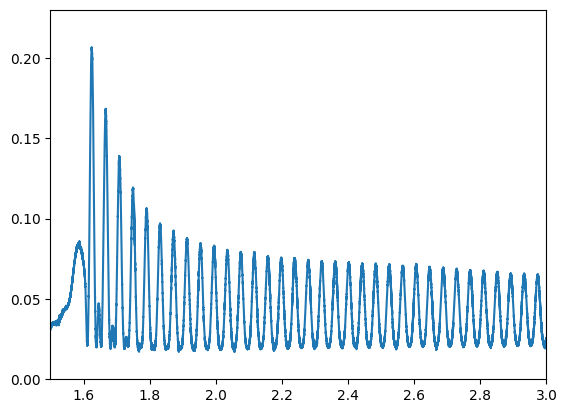

In [84]:
plt.plot(t,V)
plt.xlim(1.5,3)
plt.ylim(0,0.23)

In [ ]:
save_measurement(t, V, comment="Latón: distancia torreta a filo: 27.3 cm ")

Saved to data/measurement_20260611_121933.csv


In [ ]:
#las mediciones de antes de 

In [49]:
test = np.loadtxt("data\measurement_20260611_113943.csv", delimiter=",", skiprows=2)

In [54]:
test_t = test[:,0]
test_V = test[:,1]

(0.05, 0.15)

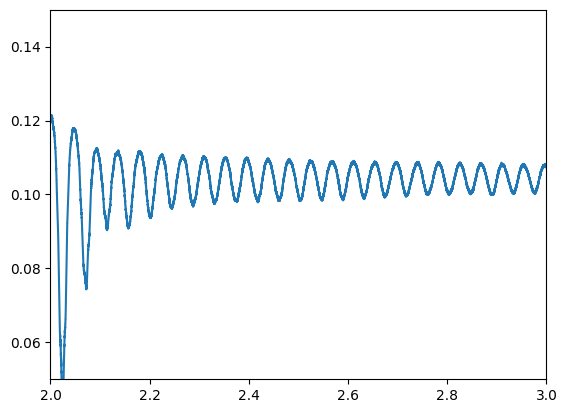

In [63]:
plt.plot(test_t,test_V) 

plt.xlim(2.0,3)
plt.ylim(0.05,0.15)
